In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             recall_score, precision_score, f1_score, make_scorer)
from sklearn.feature_selection import RFECV
from sklearn.utils.class_weight import compute_class_weight
from imblearn.under_sampling import NearMiss, RandomUnderSampler

print("="*80)
print("OTTIMIZZAZIONE MODELLI: NEARMISS E ENSEMBLE")
print("="*80)

# ==========================================
# SEZIONE 1: CARICAMENTO DATI
# ==========================================
print("\n" + "="*80)
print("SEZIONE 1: CARICAMENTO DATI")
print("="*80)

CSV_PATH = './BunkerChurners_PearsonCleaned_OutliersRemoved.csv'
df = pd.read_csv(CSV_PATH)

print(f"\n✓ Dataset caricato: {df.shape}")
print(f"Distribuzione target: {df['Attrition_Flag'].value_counts().to_dict()}")


OTTIMIZZAZIONE MODELLI: NEARMISS E ENSEMBLE

SEZIONE 1: CARICAMENTO DATI

✓ Dataset caricato: (8183, 16)
Distribuzione target: {'Existing Customer': 6857, 'Attrited Customer': 1326}


In [2]:
# ==========================================
# SEZIONE 2: PREPROCESSING SETUP
# ==========================================
print("\n" + "="*80)
print("SEZIONE 2: PREPROCESSING SETUP")
print("="*80)

variabili_numeriche = [
    'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

education_order = [['Unknown', 'Uneducated', 'High School', 'College',
                    'Graduate', 'Post-Graduate', 'Doctorate']]
income_order = [['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K',
                 '$80K - $120K', '$120K +']]

categoriche_nominali = ['Card_Category', 'Marital_Status']
categoriche_ordinali_edu = ['Education_Level']
categoriche_ordinali_inc = ['Income_Category']

# Transformers
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
ordinal_edu_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1))
])
ordinal_inc_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=income_order, handle_unknown='use_encoded_value', unknown_value=-1))
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, variabili_numeriche),
        ('ord_edu', ordinal_edu_transformer, categoriche_ordinali_edu),
        ('ord_inc', ordinal_inc_transformer, categoriche_ordinali_inc),
        ('cat', categorical_transformer, categoriche_nominali)
    ],
    remainder='drop'
)

print("\n✓ Preprocessor creato")



SEZIONE 2: PREPROCESSING SETUP

✓ Preprocessor creato


In [3]:
# ==========================================
# SEZIONE 3: TRAIN-TEST SPLIT
# ==========================================
print("\n" + "="*80)
print("SEZIONE 3: TRAIN-TEST SPLIT")
print("="*80)

X = df.drop(columns=['Attrition_Flag'])
y = df['Attrition_Flag']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n✓ Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Preprocessing dei dati
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"✓ Dati preprocessati: {X_train_processed.shape}")



SEZIONE 3: TRAIN-TEST SPLIT

✓ Train: 6546 | Test: 1637
✓ Dati preprocessati: (6546, 19)


In [4]:
# ==========================================
# FUNZIONE GRID SEARCH PERSONALIZZATA
# ==========================================
def grid_ottimiz(X, y, model, param_grid, name, cv_split, score, jobs=-1):
    """
    Esegue GridSearchCV e stampa i risultati.
    """
    print(f"\n{'='*60}")
    print(f"GRID SEARCH: {name}")
    print(f"{'='*60}")
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv_split,
        scoring=score,
        n_jobs=jobs,
        verbose=1
    )
    
    start = time.time()
    grid.fit(X, y)
    elapsed = time.time() - start
    
    results = grid.cv_results_
    best_params = grid.best_params_
    best_score = grid.best_score_
    std_score = results['std_test_score'][grid.best_index_]
    split_scores = [results[f'split{i}_test_score'][grid.best_index_] 
                   for i in range(cv_split.get_n_splits())]
    
    print(f"\n✓ Tempo di training: {elapsed:.2f}s")
    print(f"\nMigliori parametri: {best_params}")
    print(f"Score per fold: {[f'{s:.4f}' for s in split_scores]}")
    print(f"Media Recall: {best_score:.4f} (±{std_score:.4f})")
    
    return grid


In [5]:
# ==========================================
# APPROCCIO 1: NEARMISS + FEATURE SELECTION + TUNING
# ==========================================
print("\n\n" + "="*80)
print("APPROCCIO 1: NEARMISS")
print("="*80)

# Step 1: Applica NearMiss
print("\n>>> Step 1: Applicazione NearMiss")
nearmiss = NearMiss(version=2, n_jobs=-1)
X_train_nm, y_train_nm = nearmiss.fit_resample(X_train_processed, y_train)

print(f"✓ Dati dopo NearMiss: {X_train_nm.shape}")
unique, counts = np.unique(y_train_nm, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Classe {cls}: {cnt} ({cnt/len(y_train_nm)*100:.2f}%)")

# Step 2: Feature Selection con RFECV
print("\n>>> Step 2: Feature Selection (RFECV)")
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
recall_scorer = make_scorer(recall_score, pos_label=0)  # Focus sulla classe minoritaria

rfecv_nm = RFECV(
    estimator=rf_base,
    step=1,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring=recall_scorer,
    verbose=1,
    n_jobs=-1
)

start_time = time.time()
rfecv_nm.fit(X_train_nm, y_train_nm)
rfecv_time = time.time() - start_time

n_features_selected_nm = rfecv_nm.n_features_
print(f"\n✓ Feature Selection completata in {rfecv_time:.2f}s")
print(f"✓ Feature selezionate: {n_features_selected_nm}/{X_train_nm.shape[1]}")

# Trasforma i dati con le feature selezionate
X_train_nm_selected = rfecv_nm.transform(X_train_nm)
X_test_nm_selected = rfecv_nm.transform(X_test_processed)

# Step 3: Hyperparameter Tuning
print("\n>>> Step 3: Hyperparameter Tuning")
class_weights_nm = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_nm), y=y_train_nm
)
class_weight_dict_nm = {i: w for i, w in enumerate(class_weights_nm)}

param_grid_nm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [class_weight_dict_nm]
}

rf_nm = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_grid_nm = grid_ottimiz(
    X=X_train_nm_selected,
    y=y_train_nm,
    model=rf_nm,
    param_grid=param_grid_nm,
    name='NearMiss + RandomForest',
    cv_split=cv_strategy,
    score=recall_scorer,
    jobs=-1
)

# Valutazione finale
print("\n>>> Step 4: Valutazione su Test Set")
y_pred_nm = best_grid_nm.predict(X_test_nm_selected)
y_pred_proba_nm = best_grid_nm.predict_proba(X_test_nm_selected)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nm, target_names=le.classes_))
print(f"\nRecall (classe 0): {recall_score(y_test, y_pred_nm, pos_label=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_nm):.4f}")



APPROCCIO 1: NEARMISS

>>> Step 1: Applicazione NearMiss
✓ Dati dopo NearMiss: (2122, 19)
  Classe 0: 1061 (50.00%)
  Classe 1: 1061 (50.00%)

>>> Step 2: Feature Selection (RFECV)
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.

✓ Feature Selection completata in 4.79s
✓ Feature selezionate: 12/19

>>> Step 3: Hyperparameter Tuning

GRID SEARCH: NearMiss + RandomForest
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✓ Tempo di training: 66.14s

Migliori parametri: {'class_weight': {0: 1.0, 1: 1.0}, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Score per fold: ['0.9202', '0.9387', '0.9481', '0.9057', '0.9151']
Media Recall: 0.9255 (±0.0156)

>>> Step 4: Valutazione su Test Set

Confusion Matrix:
[[ 242   

In [6]:
# ==========================================
# APPROCCIO 2: RANDOM UNDERSAMPLING + ENSEMBLE + FEATURE SELECTION + TUNING
# ==========================================
print("\n\n" + "="*80)
print("APPROCCIO 2: RANDOM UNDERSAMPLING + ENSEMBLE")
print("="*80)

# Step 1: Feature Selection su un campione rappresentativo
print("\n>>> Step 1: Feature Selection (RFECV) su campione")
n_majority = (y_train == 1).sum()
n_minority = (y_train == 0).sum()
sample_size_majority = n_minority  # Bilanciamento 1:1 per feature selection

rus_fs = RandomUnderSampler(
    sampling_strategy={1: sample_size_majority, 0: n_minority},
    random_state=42
)
X_train_rus_fs, y_train_rus_fs = rus_fs.fit_resample(X_train_processed, y_train)

print(f"✓ Dati per feature selection: {X_train_rus_fs.shape}")

rfecv_ensemble = RFECV(
    estimator=rf_base,
    step=1,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring=recall_scorer,
    verbose=1,
    n_jobs=-1
)

start_time = time.time()
rfecv_ensemble.fit(X_train_rus_fs, y_train_rus_fs)
rfecv_time = time.time() - start_time

n_features_selected_ensemble = rfecv_ensemble.n_features_
print(f"\n✓ Feature Selection completata in {rfecv_time:.2f}s")
print(f"✓ Feature selezionate: {n_features_selected_ensemble}/{X_train_processed.shape[1]}")

# Trasforma i dati
X_train_selected = rfecv_ensemble.transform(X_train_processed)
X_test_selected = rfecv_ensemble.transform(X_test_processed)

# Step 2: Hyperparameter Tuning su singolo modello
print("\n>>> Step 2: Hyperparameter Tuning")
sample_size_majority_tuning = n_majority // 2

rus_tuning = RandomUnderSampler(
    sampling_strategy={1: sample_size_majority_tuning, 0: n_minority},
    random_state=42
)
X_train_rus_tuning, y_train_rus_tuning = rus_tuning.fit_resample(
    X_train_selected, y_train
)

class_weights_rus = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_rus_tuning), y=y_train_rus_tuning
)
class_weight_dict_rus = {i: w for i, w in enumerate(class_weights_rus)}

param_grid_ensemble = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [class_weight_dict_rus]
}

rf_ensemble = RandomForestClassifier(random_state=42, n_jobs=-1)

best_grid_ensemble = grid_ottimiz(
    X=X_train_rus_tuning,
    y=y_train_rus_tuning,
    model=rf_ensemble,
    param_grid=param_grid_ensemble,
    name='Ensemble + RandomForest',
    cv_split=cv_strategy,
    score=recall_scorer,
    jobs=-1
)

# Step 3: Creazione Ensemble con parametri ottimali
print("\n>>> Step 3: Creazione Ensemble (5 modelli)")
N_MODELS = 5
ensemble_models = []
best_params = best_grid_ensemble.best_params_

for i in range(N_MODELS):
    print(f"\n  Training modello {i+1}/{N_MODELS}...")
    rus = RandomUnderSampler(
        sampling_strategy={1: sample_size_majority_tuning, 0: n_minority},
        random_state=42 + i
    )
    X_train_rus, y_train_rus = rus.fit_resample(X_train_selected, y_train)
    
    # Crea modello con i migliori parametri
    model = RandomForestClassifier(
        **{k: v for k, v in best_params.items() if k != 'class_weight'},
        class_weight=class_weight_dict_rus,
        random_state=42 + i,
        n_jobs=-1
    )
    model.fit(X_train_rus, y_train_rus)
    ensemble_models.append(model)

print("\n✓ Ensemble completato")

# Step 4: Valutazione Ensemble
print("\n>>> Step 4: Valutazione Ensemble su Test Set")
ensemble_proba = np.zeros((len(X_test_selected), 2))

for model in ensemble_models:
    ensemble_proba += model.predict_proba(X_test_selected)

ensemble_proba /= N_MODELS
y_pred_ensemble = np.argmax(ensemble_proba, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ensemble))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=le.classes_))
print(f"\nRecall (classe 0): {recall_score(y_test, y_pred_ensemble, pos_label=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, ensemble_proba[:, 1]):.4f}")



APPROCCIO 2: RANDOM UNDERSAMPLING + ENSEMBLE

>>> Step 1: Feature Selection (RFECV) su campione
✓ Dati per feature selection: (2122, 19)
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.

✓ Feature Selection completata in 3.72s
✓ Feature selezionate: 12/19

>>> Step 2: Hyperparameter Tuning

GRID SEARCH: Ensemble + RandomForest
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✓ Tempo di training: 97.92s

Migliori parametri: {'class_weight': {0: 1.792177191328935, 1: 0.6934719183078045}, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Score per fold: ['0.8310', '0.8491', '0.8632', '0.8255', '0.8774']
Media Recall: 0.8492 (±0.0194)

>>> Step 3: Creazione Ensemble (5 modelli)

  Training modello 1/5...

  Traini

In [7]:
# ==========================================
# CONFRONTO FINALE
# ==========================================
print("\n\n" + "="*80)
print("CONFRONTO FINALE")
print("="*80)

results_comparison = pd.DataFrame({
    'Model': ['NearMiss + RF', 'Ensemble + RF'],
    'N_Features': [n_features_selected_nm, n_features_selected_ensemble],
    'Recall_0': [
        recall_score(y_test, y_pred_nm, pos_label=0),
        recall_score(y_test, y_pred_ensemble, pos_label=0)
    ],
    'Precision_0': [
        precision_score(y_test, y_pred_nm, pos_label=0),
        precision_score(y_test, y_pred_ensemble, pos_label=0)
    ],
    'F1_0': [
        f1_score(y_test, y_pred_nm, pos_label=0),
        f1_score(y_test, y_pred_ensemble, pos_label=0)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_pred_proba_nm),
        roc_auc_score(y_test, ensemble_proba[:, 1])
    ]
})

print("\n" + results_comparison.to_string(index=False))
print("\n" + "="*80)
print("OTTIMIZZAZIONE COMPLETATA!")
print("="*80)



CONFRONTO FINALE

        Model  N_Features  Recall_0  Precision_0     F1_0  ROC_AUC
NearMiss + RF          12  0.913208     0.394137 0.550626 0.922465
Ensemble + RF          12  0.822642     0.672840 0.740238 0.954035

OTTIMIZZAZIONE COMPLETATA!
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fit

In [8]:
# ==========================================
# ANALISI FEATURE SELEZIONATE
# ==========================================
print("\n\n" + "="*80)
print("ANALISI FEATURE SELEZIONATE")
print("="*80)

# Ottieni i nomi delle feature dopo il preprocessing
feature_names = []

# Feature numeriche
feature_names.extend(variabili_numeriche)

# Feature ordinali (Education_Level e Income_Category)
feature_names.extend(categoriche_ordinali_edu)
feature_names.extend(categoriche_ordinali_inc)

# Feature categoriche (dopo OneHotEncoding)
if len(categoriche_nominali) > 0:
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = cat_encoder.get_feature_names_out(categoriche_nominali)
    feature_names.extend(cat_feature_names)

print(f"\nTotale feature dopo preprocessing: {len(feature_names)}")

# ==========================================
# FEATURE SELEZIONATE DA NEARMISS
# ==========================================
print("\n" + "-"*80)
print("FEATURE SELEZIONATE DA NEARMISS")
print("-"*80)

selected_features_nm = [name for name, selected in zip(feature_names, rfecv_nm.support_) if selected]
rejected_features_nm = [name for name, selected in zip(feature_names, rfecv_nm.support_) if not selected]

print(f"\nNumero feature selezionate: {len(selected_features_nm)}/{len(feature_names)}")
print(f"\nLista feature selezionate:")
for i, feat in enumerate(selected_features_nm, 1):
    ranking = rfecv_nm.ranking_[feature_names.index(feat)]
    print(f"  {i:2d}. {feat:<35s} (ranking: {ranking})")

print(f"\n\nFeature eliminate ({len(rejected_features_nm)}):")
for i, feat in enumerate(rejected_features_nm, 1):
    ranking = rfecv_nm.ranking_[feature_names.index(feat)]
    print(f"  {i:2d}. {feat:<35s} (ranking: {ranking})")

# ==========================================
# FEATURE SELEZIONATE DA ENSEMBLE
# ==========================================
print("\n" + "-"*80)
print("FEATURE SELEZIONATE DA ENSEMBLE")
print("-"*80)

selected_features_ensemble = [name for name, selected in zip(feature_names, rfecv_ensemble.support_) if selected]
rejected_features_ensemble = [name for name, selected in zip(feature_names, rfecv_ensemble.support_) if not selected]

print(f"\nNumero feature selezionate: {len(selected_features_ensemble)}/{len(feature_names)}")
print(f"\nLista feature selezionate:")
for i, feat in enumerate(selected_features_ensemble, 1):
    ranking = rfecv_ensemble.ranking_[feature_names.index(feat)]
    print(f"  {i:2d}. {feat:<35s} (ranking: {ranking})")

print(f"\n\nFeature eliminate ({len(rejected_features_ensemble)}):")
for i, feat in enumerate(rejected_features_ensemble, 1):
    ranking = rfecv_ensemble.ranking_[feature_names.index(feat)]
    print(f"  {i:2d}. {feat:<35s} (ranking: {ranking})")

# ==========================================
# CONFRONTO TRA I DUE APPROCCI
# ==========================================
print("\n" + "="*80)
print("CONFRONTO FEATURE SELECTION")
print("="*80)

# Feature comuni
common_features = set(selected_features_nm) & set(selected_features_ensemble)
print(f"\nFeature selezionate da ENTRAMBI i modelli ({len(common_features)}):")
for i, feat in enumerate(sorted(common_features), 1):
    print(f"  {i:2d}. {feat}")

# Feature solo in NearMiss
only_nm = set(selected_features_nm) - set(selected_features_ensemble)
if only_nm:
    print(f"\n\nFeature selezionate SOLO da NearMiss ({len(only_nm)}):")
    for i, feat in enumerate(sorted(only_nm), 1):
        print(f"  {i:2d}. {feat}")

# Feature solo in Ensemble
only_ensemble = set(selected_features_ensemble) - set(selected_features_nm)
if only_ensemble:
    print(f"\n\nFeature selezionate SOLO da Ensemble ({len(only_ensemble)}):")
    for i, feat in enumerate(sorted(only_ensemble), 1):
        print(f"  {i:2d}. {feat}")

# ==========================================
# TABELLA COMPARATIVA
# ==========================================
print("\n" + "="*80)
print("TABELLA COMPARATIVA DETTAGLIATA")
print("="*80)

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'NearMiss_Selected': rfecv_nm.support_,
    'NearMiss_Ranking': rfecv_nm.ranking_,
    'Ensemble_Selected': rfecv_ensemble.support_,
    'Ensemble_Ranking': rfecv_ensemble.ranking_
})

# Ordina per importanza media
comparison_df['Avg_Ranking'] = (comparison_df['NearMiss_Ranking'] + comparison_df['Ensemble_Ranking']) / 2
comparison_df = comparison_df.sort_values('Avg_Ranking')

print("\n" + comparison_df.to_string(index=False))

# Salva su CSV (opzionale)
comparison_df.to_csv('feature_selection_comparison.csv', index=False)
print("\n\nTabella salvata in: feature_selection_comparison.csv")

print("\n" + "="*80)
print("ANALISI COMPLETATA!")
print("="*80)



ANALISI FEATURE SELEZIONATE

Totale feature dopo preprocessing: 19

--------------------------------------------------------------------------------
FEATURE SELEZIONATE DA NEARMISS
--------------------------------------------------------------------------------

Numero feature selezionate: 12/19

Lista feature selezionate:
   1. Months_on_book                      (ranking: 1)
   2. Total_Relationship_Count            (ranking: 1)
   3. Months_Inactive_12_mon              (ranking: 1)
   4. Contacts_Count_12_mon               (ranking: 1)
   5. Credit_Limit                        (ranking: 1)
   6. Total_Revolving_Bal                 (ranking: 1)
   7. Total_Amt_Chng_Q4_Q1                (ranking: 1)
   8. Total_Trans_Ct                      (ranking: 1)
   9. Total_Ct_Chng_Q4_Q1                 (ranking: 1)
  10. Avg_Utilization_Ratio               (ranking: 1)
  11. Education_Level                     (ranking: 1)
  12. Income_Category                     (ranking: 1)


Feature eli

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_score, f1_score, confusion_matrix

# ===============================
# COMPARAZIONE VISIVA TRA MODELLI
# ===============================

# Metriche principali
metrics_dict = {
    'Modello': ['NearMiss', 'Ensemble'],
    'Recall (classe 0)': [
        recall_score(y_test, y_pred_nm, pos_label=0),
        recall_score(y_test, y_pred_ensemble, pos_label=0)
    ],
    'Precision (classe 0)': [
        precision_score(y_test, y_pred_nm, pos_label=0),
        precision_score(y_test, y_pred_ensemble, pos_label=0)
    ],
    'F1-score (classe 0)': [
        f1_score(y_test, y_pred_nm, pos_label=0),
        f1_score(y_test, y_pred_ensemble, pos_label=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_nm),
        roc_auc_score(y_test, ensemble_proba[:, 1])
    ]
}

# Colori pastello scelti
color_nearmiss = "#F4A6A3" #rosso melograno pastello "#A8D5BA"   # verde pastello
color_ensemble = "#A8C8E4"   # azzurro pastello

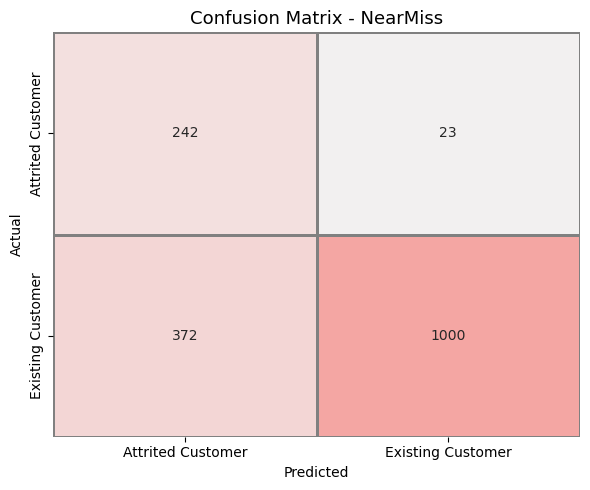

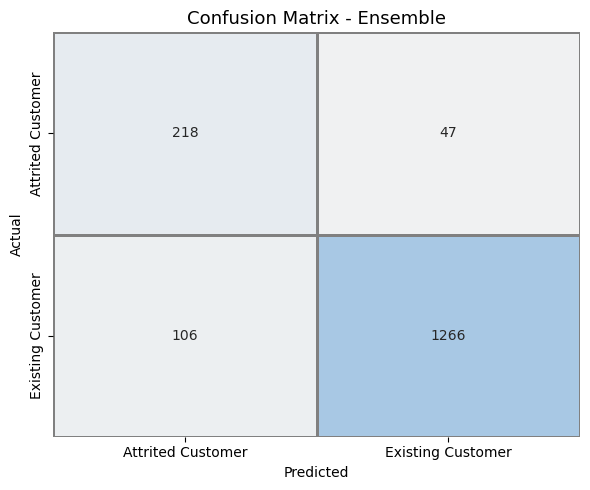

In [16]:
# ========================
# PLOT 1: Confusion Matrix
# ========================
def plot_conf_matrix(y_true, y_pred, title, filename, cmap_color):
    cm = confusion_matrix(y_true, y_pred)
    labels = le.classes_
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(cmap_color, as_cmap=True),
                xticklabels=labels, yticklabels=labels, cbar=False, linewidths=1, linecolor='gray')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Confusion matrix NearMiss
plot_conf_matrix(
    y_true=y_test,
    y_pred=y_pred_nm,
    title='Confusion Matrix - NearMiss',
    filename='conf_matrix_nearmiss.png',
    cmap_color=color_nearmiss
)

# Confusion matrix Ensemble
plot_conf_matrix(
    y_true=y_test,
    y_pred=y_pred_ensemble,
    title='Confusion Matrix - Ensemble',
    filename='conf_matrix_ensemble.png',
    cmap_color=color_ensemble
)

<Figure size 1000x600 with 0 Axes>

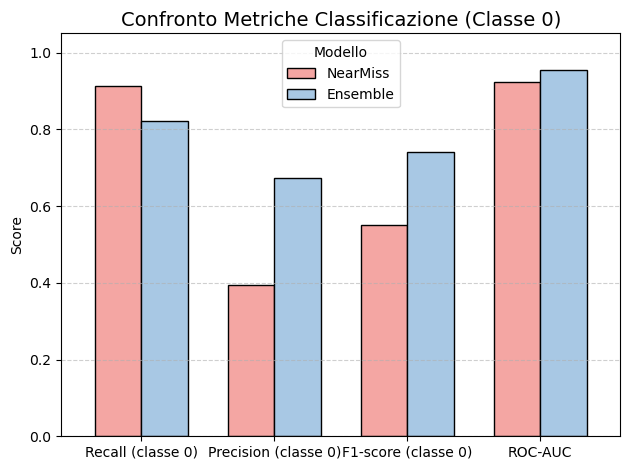

In [17]:
# ========================
# PLOT 2: Metrics Bar Plot
# ========================
df_metrics = pd.DataFrame(metrics_dict).set_index('Modello').T

plt.figure(figsize=(10, 6))
df_metrics.plot(kind='bar',
                color=[color_nearmiss, color_ensemble],
                edgecolor='black',
                width=0.7)

plt.title('Confronto Metriche Classificazione (Classe 0)', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Modello')
plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()
